# Assignment 4: Regularization

In [1]:
! git clone https://github.com/kayleendo/scratchpad
%run ./scratchpad/get_data.py

Cloning into 'scratchpad'...
remote: Enumerating objects: 30, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 30 (delta 5), reused 4 (delta 4), pack-reused 20 (from 1)
Receiving objects: 100% (30/30), 45.46 KiB | 1.75 MiB/s, done.
Resolving deltas: 100% (6/6), done.
Download complete
Extracting data files...
Data extracted


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.pipeline import Pipeline

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?
2. How does regularization provide a way of exploring the bias-variance trade-off?
3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?
4. How do we typically scale variables for use in regularized regression? Why?
5. How is the penalty $\alpha$ typically selected?
6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?

1. Since large coefficients mean that the model is very sensitive to small changes, this often indicates overfitting. We add a penalty that grows based on the size of the coefficient to fit the data and simplify coefficients.

2. Without regularization, there is low biad and high variance. With strong regularization, the model has high biand and low variance. Changing the value of regularization lets us explore complex and simple models, and allows us to control overfitting.

3. LASSO regression has an absolute penalty and can shrink coefficients to exactly 0. Ridge regression has a squared penalty and shrinks coefficients towards 0. LASSO regression selects a subset of variables, while ridge regression keeps all variables but at a smaller weight. Models that use LASSO regression are sparser, while models that use ridge regression are not.

4. We scale variables by centering the mean at 0 and the standard deviation at 1. This is because the penalty depends on the coefficient size. If variables are not scaled, larger variables get penalized more, while smaller variables get penalized less. Scaling ensures that all variables are penalized equally so coefficients are comparable.

5. The penalty is selected by using cross validation. For each α we try, we fit the model on training folds and compute the validation error. Then the α that minimizes validation MSE is chosen.

6. We do not include the penalty because we care about prediction performance on new data. Pnelaty is only used to control model complexity during training, and is not part of the actual prediction error. The penalty helps us choose the model but we judge the model based on how well it predicts.

**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them.
2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero?
7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

In [5]:
# 1
df = pd.read_csv("/content/data/cars_hw.csv")

current_year = 2026
df['Age'] = current_year - df['Make_Year']

X = df[['Mileage_Run', 'Age']]
y = df['Price']
poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X)

feature_names = poly.get_feature_names_out(['Mileage_Run', 'Age'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

In [6]:
# 2
linreg = LinearRegression()
linreg.fit(X_scaled, y)

coeffs = pd.Series(linreg.coef_, index=feature_names)
print(coeffs)

Mileage_Run          9.117748e+05
Age                 -2.481722e+05
Mileage_Run^2       -2.072926e+05
Mileage_Run Age     -1.671212e+06
Age^2                3.505507e+05
Mileage_Run^3       -6.514490e+04
Mileage_Run^2 Age    3.388195e+05
Mileage_Run Age^2    7.167816e+05
Age^3               -2.100379e+05
dtype: float64


The sign of interaction is negative, meaning that high mileage and high age reduces price.

In [7]:
# 3
alphas = np.logspace(1, 3, 20)

lasso = LassoCV(alphas=alphas, cv=20, max_iter=100000)
lasso.fit(X_scaled, y)

print("Best alpha:", lasso.alpha_)

Best alpha: 88.58667904100822


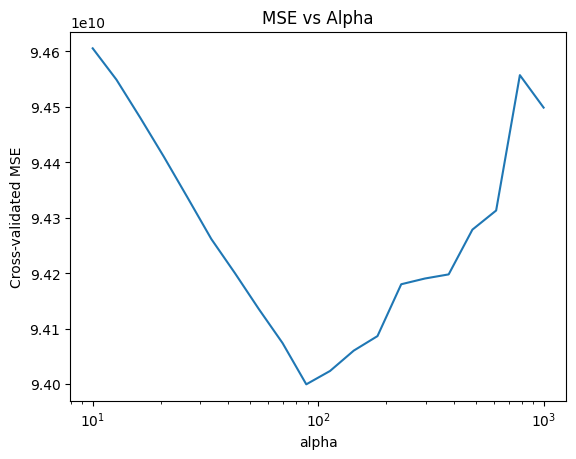

In [8]:
# 4
mse_path = lasso.mse_path_.mean(axis=1)

plt.figure()
plt.plot(lasso.alphas_, mse_path)
plt.xscale('log')
plt.xlabel("alpha")
plt.ylabel("Cross-validated MSE")
plt.title("MSE vs Alpha")
plt.show()

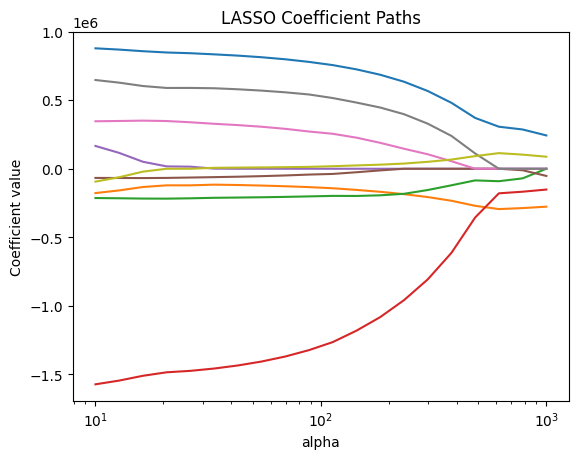

In [9]:
# 5
coefs = []

for a in alphas:
    l = LassoCV(alphas=[a], cv=20, max_iter=100000)
    l.fit(X_scaled, y)
    coefs.append(l.coef_)

coefs = np.array(coefs)

plt.figure()
for i in range(coefs.shape[1]):
    plt.plot(alphas, coefs[:, i])

plt.xscale('log')
plt.xlabel("alpha")
plt.ylabel("Coefficient value")
plt.title("LASSO Coefficient Paths")
plt.show()

In [10]:
# 6
lasso_coefs = pd.Series(lasso.coef_, index=feature_names)

selected = lasso_coefs[lasso_coefs != 0]
zeroed = lasso_coefs[lasso_coefs == 0]

print("Selected features:\n", selected)
print("\nProportion zero:", len(zeroed) / len(lasso_coefs))

Selected features:
 Mileage_Run          7.790762e+05
Age                 -1.339534e+05
Mileage_Run^2       -2.015634e+05
Mileage_Run Age     -1.322419e+06
Mileage_Run^3       -4.240952e+04
Mileage_Run^2 Age    2.715062e+05
Mileage_Run Age^2    5.415432e+05
Age^3                1.374220e+04
dtype: float64

Proportion zero: 0.1111111111111111


In [11]:
# 7
comparison = pd.DataFrame({
    "Linear": linreg.coef_,
    "LASSO": lasso.coef_
}, index=feature_names)

print(comparison)

                         Linear         LASSO
Mileage_Run        9.117748e+05  7.790762e+05
Age               -2.481722e+05 -1.339534e+05
Mileage_Run^2     -2.072926e+05 -2.015634e+05
Mileage_Run Age   -1.671212e+06 -1.322419e+06
Age^2              3.505507e+05  0.000000e+00
Mileage_Run^3     -6.514490e+04 -4.240952e+04
Mileage_Run^2 Age  3.388195e+05  2.715062e+05
Mileage_Run Age^2  7.167816e+05  5.415432e+05
Age^3             -2.100379e+05  1.374220e+04


In general, coefficients decrease in magnitude. Age^3 changes its sign from negative to positive.

**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.
2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?
2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.
3. How does increasing $\alpha$ change the slope coefficient?
4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?